### Financial Market Analytics

In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


In [24]:
tickers = [ # Claude
    # Equity - Developed Markets
    "SPY",   # S&P 500
    "QQQ",   # Nasdaq-100
    "VGK",   # Europe
    "EWJ",   # Japan
    "VPL",   # Asia-Pacific

    # Equity - Emerging Markets
    "EEM",   # MSCI EM
    "VWO",   # FTSE EM

    # Government Bonds
    "SHY",   # 1-3Y Treasury
    "IEF",   # 7-10Y Treasury
    "TLT",   # 20+Y Treasury
    "IGOV",  # Intl Treasury
    "EMB",   # EM Bond USD

    # Credit
    "LQD",   # IG Corporate
    "HYG",   # High Yield
    #"BKLN",  # Senior Loans

    # Commodities & Inflation
    "GLD",   # Gold
    "SLV",   # Silver
    "DBC",   # Broad Commodity
    "XLE",   # Energy Equity
    "TIP",   # TIPS
    "USO",

    # REIT
    "VNQ",   # US REIT
    #"VNQI",  # Global REIT

    # Cash & Alternatives
    "BIL",   # T-Bill (risk-free proxy)
    #"PDBC",  # Optimum Yield Commodity
    #"DBMF",  # Managed Futures
]

In [25]:
prices = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
print(prices.isna().sum())
prices = prices.dropna(how="all")  # rimuove date senza dati
monthly_prices = prices.resample('M').last()
monthly_returns = monthly_prices.pct_change().dropna()

[*********************100%***********************]  22 of 22 completed

Ticker
BIL     0
DBC     0
EEM     0
EMB     0
EWJ     0
GLD     0
HYG     0
IEF     0
IGOV    0
LQD     0
QQQ     0
SHY     0
SLV     0
SPY     0
TIP     0
TLT     0
USO     0
VGK     0
VNQ     0
VPL     0
VWO     0
XLE     0
dtype: int64



C:\Users\tomma\AppData\Local\Temp\ipykernel_5800\2687429117.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = prices.resample('M').last()


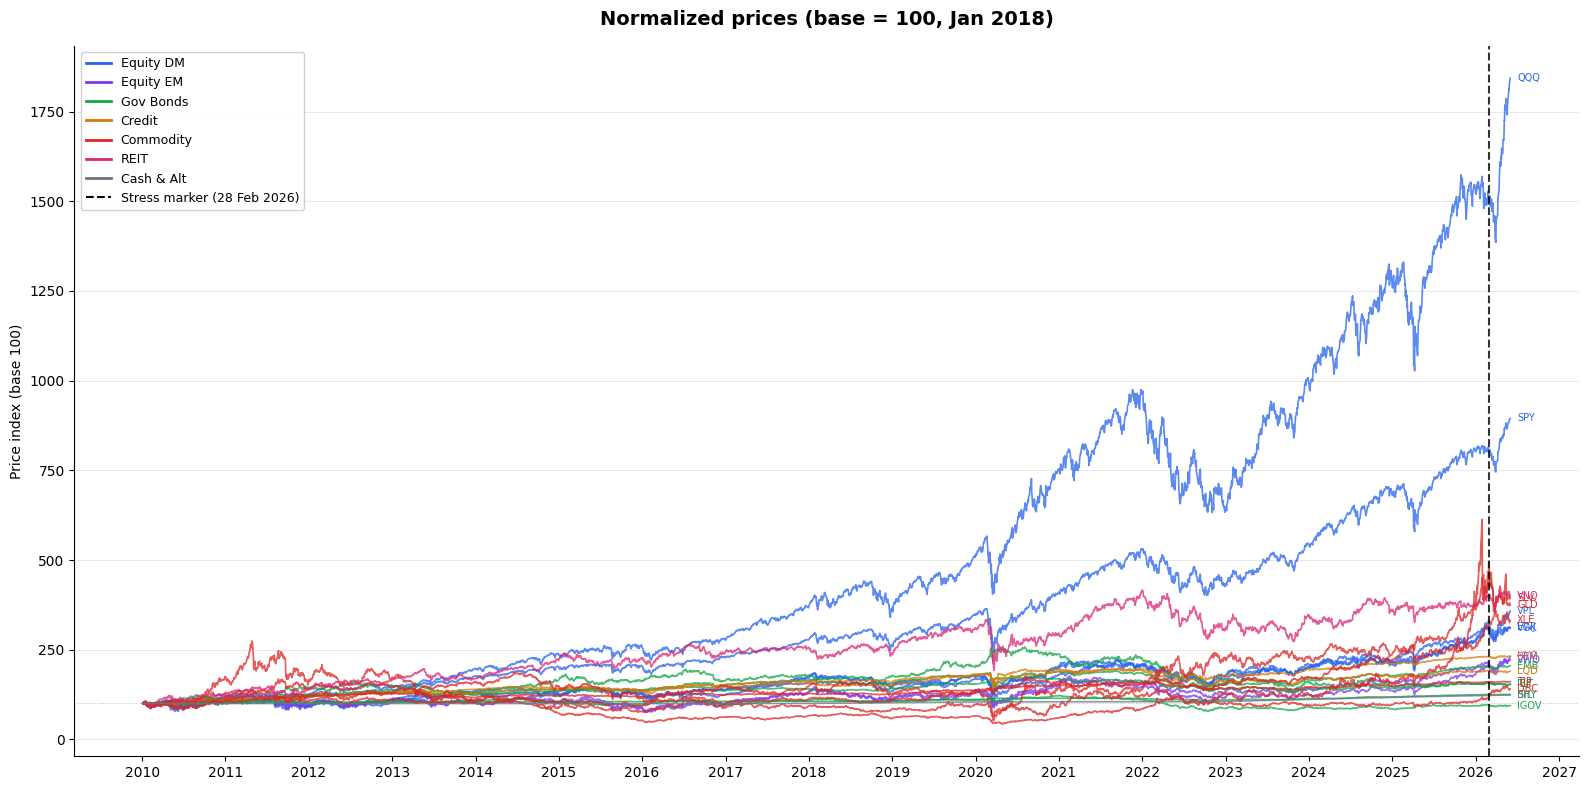

In [26]:
# Normalizza a 100 al primo giorno disponibile per ogni ticker
normalized = prices / prices.bfill().iloc[0] * 100

# Gruppi per colore
groups = {
    "Equity DM":   (["SPY", "QQQ", "VGK", "EWJ", "VPL"], "#2563EB"),
    "Equity EM":   (["EEM", "VWO"],                        "#7C3AED"),
    "Gov Bonds":   (["SHY", "IEF", "TLT", "IGOV", "EMB"], "#16A34A"),
    "Credit":      (["LQD", "HYG", "BKLN"],                "#D97706"),
    "Commodity":   (["GLD", "SLV", "DBC", "XLE", "TIP"],  "#DC2626"),
    "REIT":        (["VNQ", "VNQI"],                        "#DB2777"),
    "Cash & Alt":  (["BIL", "PDBC", "DBMF"],               "#6B7280"),
}

fig, ax = plt.subplots(figsize=(16, 8))

for group_name, (group_tickers, color) in groups.items():
    for i, ticker in enumerate(group_tickers):
        if ticker not in normalized.columns:
            continue
        ax.plot(
            normalized.index,
            normalized[ticker],
            color=color,
            linewidth=1.2,
            alpha=0.75,
            label=f"{ticker}" if i == 0 else "_nolegend_",  # solo primo per la legenda colore
        )
        # Label inline alla fine della linea
        last_val = normalized[ticker].dropna().iloc[-1]
        ax.annotate(
            ticker,
            xy=(normalized[ticker].dropna().index[-1], last_val),
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=7,
            color=color,
            va="center",
        )

# Linea verticale: finestra di stress recente
ax.axvline(
    x=np.datetime64("2026-02-28"),
    color="black",
    linewidth=1.5,
    linestyle="--",
    alpha=0.8,
    label="Stress marker (28 Feb 2026)",
)
ax.axhline(y=100, color="gray", linewidth=0.7, linestyle=":", alpha=0.5)

# Legenda gruppi (solo colori)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=color, linewidth=2, label=name)
    for name, (_, color) in groups.items()
]
legend_handles.append(
    Line2D([0], [0], color="black", linewidth=1.5, linestyle="--", label="Stress marker (28 Feb 2026)")
)
ax.legend(handles=legend_handles, loc="upper left", fontsize=9, framealpha=0.9)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_title("Normalized prices (base = 100, Jan 2018)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Price index (base 100)")
ax.set_xlabel("")
ax.grid(axis="y", linewidth=0.5, alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("normalized_prices.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
n = len(tickers)
w_ew = np.ones(n) / n  # 4% each

In [28]:
# Equity = SPY, QQQ, VGK, EWJ, VPL, EEM, VWO → 60% diviso in parti uguali
# Bonds  = SHY, IEF, TLT, IGOV, EMB, LQD      → 40% diviso in parti uguali

equity_tickers = ["SPY", "QQQ", "VGK", "EWJ", "VPL", "EEM", "VWO"]
bond_tickers   = ["SHY", "IEF", "TLT", "IGOV", "EMB", "LQD"]

w_6040 = {}
for t in equity_tickers:
    w_6040[t] = 0.60 / len(equity_tickers)
for t in bond_tickers:
    w_6040[t] = 0.40 / len(bond_tickers)
# tutto il resto = 0

## 1. Exploratory Data Analysis (EDA)

Before applying complex portfolio optimization models, it is crucial to understand the historical behavior of our asset universe. Exploratory Data Analysis (EDA) allows us to identify long-term trends, volatility clusters, and regime shifts.

In financial markets, macroeconomic shocks and geopolitical stress periods can alter asset dynamics substantially. By highlighting the recent **2025-2026 stress window** on the performance charts, we can visually assess which assets behaved more defensively (e.g., Gold, US Treasuries) and which experienced larger drawdowns, without attributing the move to an undocumented single event.


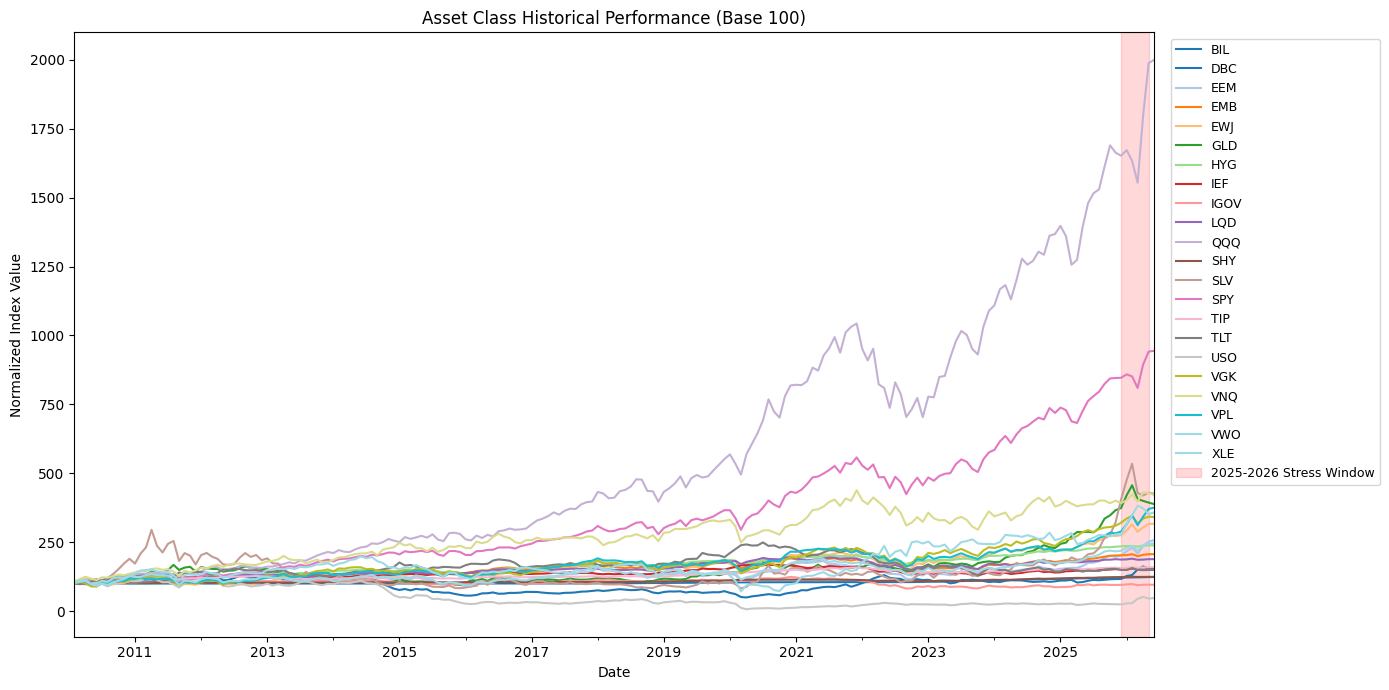

In [29]:
monthly_prices = prices.resample('ME').last()
log_returns = np.log(monthly_prices / monthly_prices.shift(1)).dropna()
# Plot 1: Normalized Historical Performance
plt.figure(figsize=(14, 7))
p_norm = (np.exp(log_returns.cumsum()) * 100)
p_norm.plot(colormap='tab20', linewidth=1.5, ax=plt.gca())

# Highlight a recent geopolitical / macro stress window without attributing it to one unverified event.
plt.axvspan('2025-12-31', '2026-05-31', color='red', alpha=0.15, label='2025-2026 Stress Window')

plt.title('Asset Class Historical Performance (Base 100)')
plt.ylabel('Normalized Index Value')
plt.xlabel('Date')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()


### 1.1 Cross-Asset Correlation Matrix

The foundation of modern diversification is asset correlation. According to Markowitz, holding assets that are not perfectly positively correlated reduces overall portfolio variance. 

The **Correlation Matrix** provides a snapshot of these linear relationships. A value close to +1 indicates assets move together, while a value close to -1 indicates they move in opposite directions. It is important to note that during severe market crashes or wars, correlations tend to converge toward 1 (all risky assets fall together), making traditional diversification less effective.

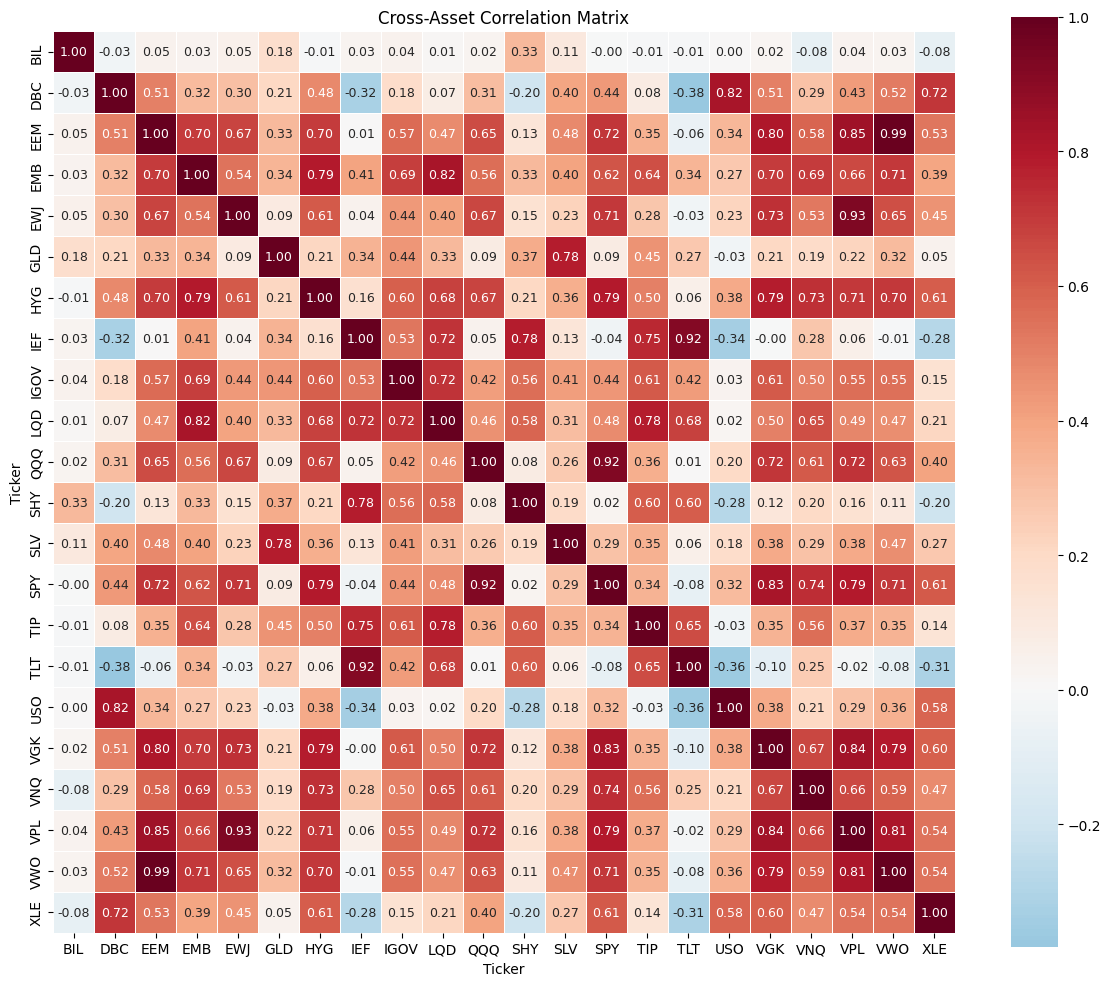

In [30]:
# Plot 2: Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix of the log returns
corr_matrix = log_returns.corr()

# Use Seaborn to plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, annot_kws={"size": 9}, linewidths=.5)

plt.title('Cross-Asset Correlation Matrix')
plt.tight_layout()
plt.show()



### 1.2 Stress Regime: Correlation Convergence Analysis

A fundamental stylized fact of financial markets is that **correlations are not static**. During periods of severe geopolitical or macro-financial stress, cross-asset correlations can experience structural breaks.

This phenomenon, known as **Correlation Convergence** or the *Contagion Effect*, implies that during a panic, investors may liquidate risky assets indiscriminately. As a result, previously uncorrelated assets can suddenly exhibit correlations approaching +1.0. This is the Achilles' heel of classical Mean-Variance optimization: diversification benefits tend to disappear precisely when they are needed the most.

By isolating log returns over the recent 2025-2026 stress window, we can visualize a stress-period correlation matrix and compare it to the historical average.


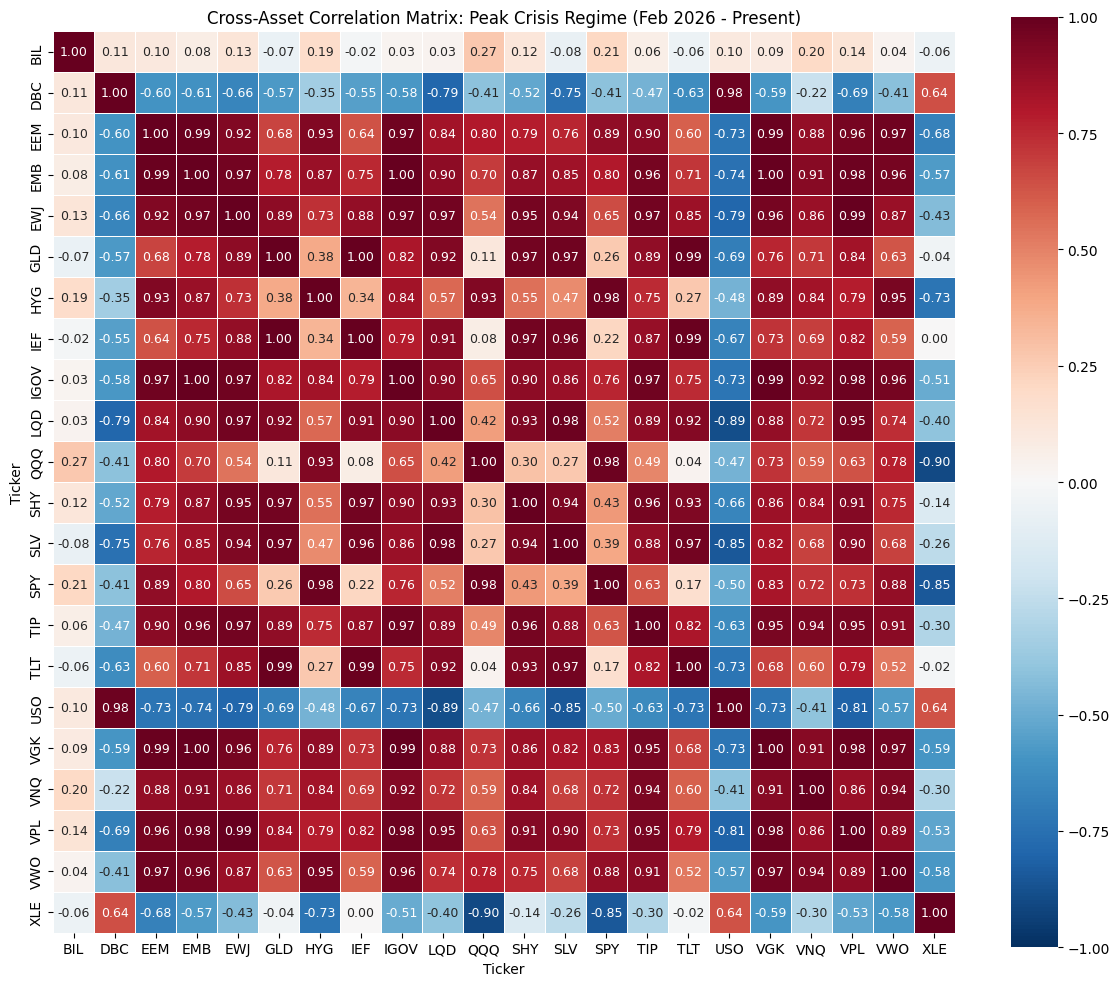

>>> Average Historical Cross-Asset Correlation: 0.336
>>> Average Crisis-Regime Cross-Asset Correlation: 0.377
>>> Correlation Jump (Contagion): 0.041


In [31]:
# Define the start date of the severe crisis period
crisis_start_date = '2026-02-01'

# Slice the log returns dataframe to isolate the war period
crisis_returns = log_returns.loc[crisis_start_date:]

# Calculate the correlation matrix specifically for the crisis regime
crisis_corr_matrix = crisis_returns.corr()

# Plot 2b: Crisis Period Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))

# Use a consistent color map and scale (vmin=-1, vmax=1) to allow direct comparison with the previous heatmap
sns.heatmap(crisis_corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, annot_kws={"size": 9}, linewidths=.5)

plt.title('Cross-Asset Correlation Matrix: Peak Crisis Regime (Feb 2026 - Present)')
plt.tight_layout()
plt.show()

# Optional analytical step: Calculate the average correlation jump
# We extract the upper triangle of the matrices to avoid duplicating values and the diagonal (1.0s)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
hist_avg_corr = corr_matrix.where(mask).mean().mean()
crisis_avg_corr = crisis_corr_matrix.where(mask).mean().mean()

print(f">>> Average Historical Cross-Asset Correlation: {hist_avg_corr:.3f}")
print(f">>> Average Crisis-Regime Cross-Asset Correlation: {crisis_avg_corr:.3f}")
print(f">>> Correlation Jump (Contagion): {(crisis_avg_corr - hist_avg_corr):.3f}")

## 2. Modern Portfolio Theory: The Markowitz Model

Introduced by Harry Markowitz in 1952, **Mean-Variance Optimization** forms the basis of Modern Portfolio Theory (MPT). The framework assumes investors are rational and risk-averse, seeking to maximize expected returns for a given level of risk (variance), or minimize risk for a target return.

Key concepts in this implementation:
1. **Expected Returns ($\mu$)**: Estimated here using historical sample means.
2. **Covariance Matrix ($\Sigma$)**: Captures individual asset volatilities and cross-asset correlations.
3. **Efficient Frontier**: The set of optimal portfolios that offer the highest expected return for a defined level of risk. Portfolios lying below the frontier are sub-optimal.
4. **Max Sharpe Portfolio (Tangency Portfolio)**: The specific portfolio on the efficient frontier that maximizes the risk-adjusted return (Sharpe Ratio). It is the point where the Capital Allocation Line (CAL) is tangent to the efficient frontier.

In [32]:
from scipy.optimize import minimize

# Annualize the expected returns and covariance matrix (multiplying by 12 for monthly data)
mu_hist = log_returns.mean().values * 12
sigma_hist = log_returns.cov().values * 12
asset_names = log_returns.columns.tolist()
rf_rate = 0.02 # Assuming a 2% risk-free rate

def get_max_sharpe_weights(mu: np.ndarray, sigma_matrix: np.ndarray, rf_rate: float = 0.02) -> np.ndarray:
    """Computes long-only portfolio weights maximizing the Sharpe Ratio via SLSQP optimization."""
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets
    
    # Objective function to minimize (Negative Sharpe Ratio)
    def neg_sharpe(w):
        p_ret = np.dot(w, mu)
        p_vol = np.sqrt(np.dot(w.T, np.dot(sigma_matrix, w)))
        if p_vol == 0: return 0
        return -(p_ret - rf_rate) / p_vol

    # Constraints: fully invested (sum of weights = 1) and long-only bounds (0 to 1)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    res = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=constraints, options={'ftol': 1e-10})
    return res.x if res.success else w0

def build_efficient_frontier(mu: np.ndarray, sigma_matrix: np.ndarray, n_points: int = 50) -> tuple:
    """Traces out the long-only efficient frontier curve."""
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets
    
    # 1. Find Minimum Variance Portfolio (MVP) to set the lower bound of the frontier
    res_mvp = minimize(lambda w: w @ sigma_matrix @ w, w0, method='SLSQP',
                       bounds=[(0, 1)] * n_assets, constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}])
    
    min_ret = res_mvp.x @ mu
    max_ret = mu.max() * 0.999 # Max possible return is heavily concentrated in the highest-returning asset
    
    # Generate target returns between MVP and Max Return
    targets = np.linspace(min_ret, max_ret, n_points)
    f_vols, f_rets, f_weights = [], [], []
    
    # 2. Minimize variance for each target return
    for t in targets:
        cons = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}, 
                {'type': 'eq', 'fun': lambda w: w @ mu - t}]
        res = minimize(lambda w: w @ sigma_matrix @ w, w0, method='SLSQP', bounds=[(0, 1)] * n_assets, constraints=cons)
        if res.success:
            f_vols.append(np.sqrt(res.x @ sigma_matrix @ res.x))
            f_rets.append(res.x @ mu)
            f_weights.append(res.x)
            
    return np.array(f_vols), np.array(f_rets), np.array(f_weights)

# Compute Max Sharpe Portfolio and the Frontier
opt_weights_ms = get_max_sharpe_weights(mu_hist, sigma_hist, rf_rate)
opt_ret_ms = np.dot(opt_weights_ms, mu_hist)
opt_vol_ms = np.sqrt(np.dot(opt_weights_ms.T, np.dot(sigma_hist, opt_weights_ms)))

frontier_vols, frontier_rets, frontier_weights = build_efficient_frontier(mu_hist, sigma_hist)

print(">>> Optimization completed.")

>>> Optimization completed.


In [33]:
def get_min_variance_target_return_weights(mu: np.ndarray, sigma_matrix: np.ndarray, target_return: float) -> np.ndarray:
    """
    Computes the Markowitz min-variance portfolio for a specific target return.
    
    Mathematical Formulation:
    Minimize: (1/2) * w^T * Sigma * w
    Subject to:
        1) w^T * mu = mu_target
        2) w^T * 1 = 1
        3) w >= 0 (Long-only constraint)
    """
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets
    
    # Objective Function: Minimize Variance
    def portfolio_variance(w):
        return np.dot(w.T, np.dot(sigma_matrix, w))

    # Constraints mapping exactly to the assignment requirements
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},               # Constraint: w^T 1 = 1 (Fully invested)
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return} # Constraint: w^T mu = mu_target
    )
    
    # Long-only bounds (0 to 1 for each asset)
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    res = minimize(portfolio_variance, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return res.x if res.success else w0


In [34]:

# --- STEP 1: Define Anchor Portfolios ---

# 1a. Compute Global Minimum Variance (GMV) Portfolio Weights
def get_gmv_weights(sigma_matrix: np.ndarray) -> np.ndarray:
    """Computes long-only weights for the Global Minimum Variance Portfolio."""
    n_assets = sigma_matrix.shape[0]
    w0 = np.ones(n_assets) / n_assets
    
    # Objective: minimize pure variance (no return constraint)
    def portfolio_variance(w):
        return np.dot(w.T, np.dot(sigma_matrix, w))
    
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    res = minimize(portfolio_variance, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x if res.success else w0

# Extract weights for the two anchor strategies
weights_gmv = get_gmv_weights(sigma_hist)
weights_ms = get_max_sharpe_weights(mu_hist, sigma_hist, rf_rate)

# Calculate expected returns for both anchor portfolios
mu_gmv = np.dot(weights_gmv, mu_hist)
mu_ms = np.dot(weights_ms, mu_hist)

# --- STEP 2: Convex Interpolation ---

# Set your risk propensity parameter alpha here (alpha in [0, 1])
# alpha = 0.0 -> Pure GMV (minimum risk)
# alpha = 1.0 -> Pure Max-Sharpe (maximum efficiency)
# alpha = 0.5 -> Balanced compromise exactly halfway on the efficient frontier
alpha = 0.5 

# Mathematically guaranteed to be feasible on the efficient frontier
dynamic_mu_target = (1 - alpha) * mu_gmv + alpha * mu_ms

# --- STEP 3: Final Optimization with Feasible Target ---

# Compute final optimized weights using your existing target-return function
optimized_weights_convex = get_min_variance_target_return_weights(
    mu_hist, 
    sigma_hist, 
    dynamic_mu_target
)

# --- STEP 4: Performance Evaluation ---
convex_portfolio_return = np.dot(optimized_weights_convex, mu_hist)
convex_portfolio_volatility = np.sqrt(np.dot(optimized_weights_convex.T, np.dot(sigma_hist, optimized_weights_convex)))

print(">>> Convex Interpolation Target Setting Completed.")
print(f"Anchor GMV Return (alpha=0):         {mu_gmv*100:.2f}%")
print(f"Anchor Max-Sharpe Return (alpha=1):   {mu_ms*100:.2f}%")
print(f"Selected Alpha:                      {alpha}")
print(f"Dynamically Calculated Target Mu:    {dynamic_mu_target*100:.2f}%")
print("-" * 50)
print(f"Final Portfolio Realized Return:     {convex_portfolio_return*100:.2f}%")
print(f"Final Portfolio Volatility:          {convex_portfolio_volatility*100:.2f}%")

>>> Convex Interpolation Target Setting Completed.
Anchor GMV Return (alpha=0):         1.32%
Anchor Max-Sharpe Return (alpha=1):   15.55%
Selected Alpha:                      0.5
Dynamically Calculated Target Mu:    8.43%
--------------------------------------------------
Final Portfolio Realized Return:     8.43%
Final Portfolio Volatility:          6.96%


In [35]:
from scipy.optimize import minimize
import numpy as np

def get_max_utility_weights(mu: np.ndarray, sigma_matrix: np.ndarray, risk_aversion: float = 3.0) -> np.ndarray:
    """
    Computes the portfolio weights that maximize the Mean-Variance Utility function.
    
    Mathematical Formulation:
    Maximize: U = w^T * mu - (lambda/2) * w^T * Sigma * w
    
    Equivalent to Minimizing the Negative Utility:
    Minimize: (lambda/2) * w^T * Sigma * w - w^T * mu
    
    Subject to:
        1) w^T * 1 = 1 (Fully invested / Budget constraint)
        2) w >= 0 (Long-only constraint)
    """
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets
    
    # Obiettivo: Minimizzare la "Disutilità" (Negativo dell'Utilità)
    def negative_utility(w):
        expected_return = np.dot(w, mu)
        portfolio_variance = np.dot(w.T, np.dot(sigma_matrix, w))
        
        # Calcolo di -U
        return (risk_aversion / 2.0) * portfolio_variance - expected_return

    # Vincoli: teniamo solo il vincolo di bilancio (fully invested)
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1} 
    )
    
    # Bounds: Long-only (0 to 1 per ogni asset)
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    # Esecuzione dell'ottimizzazione tramite SLSQP
    res = minimize(negative_utility, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return res.x if res.success else w0

# --- ESEMPIO DI UTILIZZO ---
# Definiamo il parametro di avversione al rischio lambda (es. 3 per un profilo moderato)
lambda_param = 3.0

# Calcoliamo i pesi
opt_weights_utility = get_max_utility_weights(mu_hist, sigma_hist, lambda_param)

# Metriche del portafoglio risultante
opt_ret_utility = np.dot(opt_weights_utility, mu_hist)
opt_vol_utility = np.sqrt(np.dot(opt_weights_utility.T, np.dot(sigma_hist, opt_weights_utility)))
opt_utility_score = opt_ret_utility - (lambda_param / 2.0) * (opt_vol_utility**2)

print(f">>> Max Utility Portfolio (lambda = {lambda_param}):")
print(f"Expected Return:      {opt_ret_utility*100:.2f}%")
print(f"Volatility:           {opt_vol_utility*100:.2f}%")
print(f"Maximized Utility (U): {opt_utility_score:.4f}")

>>> Max Utility Portfolio (lambda = 3.0):
Expected Return:      18.25%
Volatility:           17.36%
Maximized Utility (U): 0.1373


### 2.1 Visualizing the Efficient Frontier

The plot below visualizes the risk-return space.
* **Blue Line**: The Classical Markowitz Efficient Frontier.
* **Red Star**: The Maximum Sharpe Ratio Portfolio (tangency portfolio).
* **Grey Dots**: Individual assets plotted in the same space, illustrating the power of diversification (the frontier is generally shifted to the top-left relative to individual assets).

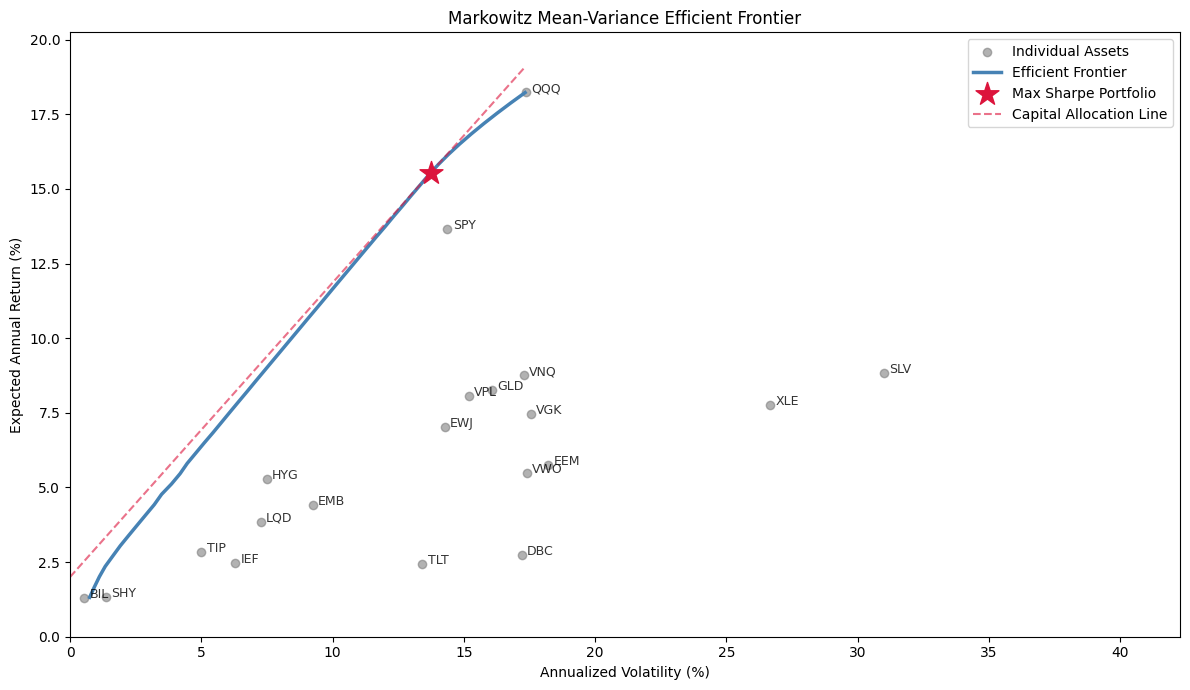


Maximum Sharpe Portfolio Allocation:
     Weight (%)
QQQ       72.99
GLD       27.01


In [36]:
# Plot 3: Efficient Frontier and Max Sharpe Portfolio
plt.figure(figsize=(12, 7))

# Plot individual assets
asset_vols = np.sqrt(np.diag(sigma_hist))
plt.scatter(asset_vols * 100, mu_hist * 100, color='grey', marker='o', alpha=0.6, label='Individual Assets')

# Annotate individual assets
for i, txt in enumerate(asset_names):
    plt.annotate(txt, (asset_vols[i] * 100 + 0.2, mu_hist[i] * 100), fontsize=9, alpha=0.8)
# Plot the Efficient Frontier
plt.plot(frontier_vols * 100, frontier_rets * 100, color='steelblue', lw=2.5, label='Efficient Frontier')

# Plot the Max Sharpe Portfolio
plt.scatter(opt_vol_ms * 100, opt_ret_ms * 100, color='crimson', marker='*', s=300, zorder=5, label='Max Sharpe Portfolio')

# Plot the Capital Allocation Line (CAL) approximation
cal_x = np.linspace(0, max(frontier_vols)*100, 20)
cal_y = rf_rate*100 + cal_x * ((opt_ret_ms - rf_rate) / opt_vol_ms)
plt.plot(cal_x, cal_y, color='crimson', linestyle='--', alpha=0.6, label='Capital Allocation Line')

plt.xlim(0, max(asset_vols)*100 + 2)
plt.ylim(0, max(mu_hist)*100 + 2)
plt.xlabel('Annualized Volatility (%)')
plt.ylabel('Expected Annual Return (%)')
plt.title('Markowitz Mean-Variance Efficient Frontier')
plt.legend()
plt.tight_layout()
plt.show()

# Display Max Sharpe Weights
ms_weights_df = pd.DataFrame({'Weight (%)': np.round(opt_weights_ms * 100, 2)}, index=asset_names)
print("\nMaximum Sharpe Portfolio Allocation:")
print(ms_weights_df[ms_weights_df['Weight (%)'] > 0.1].sort_values(by='Weight (%)', ascending=False))

### 2.2 Portfolio Composition Map

While the frontier curve shows risk vs. return, it doesn't show *what* we are actually buying. The area chart below illustrates the asset class transition as we move along the efficient frontier. 

* On the far left (Minimum Variance), the portfolio is dominated by low-volatility assets (e.g., Short-term Treasuries like `SHV`).
* As we move to the right (seeking higher expected returns), the optimizer aggressively shifts capital toward the riskiest, highest-yielding assets, eventually concentrating entirely in a single asset at the far right.

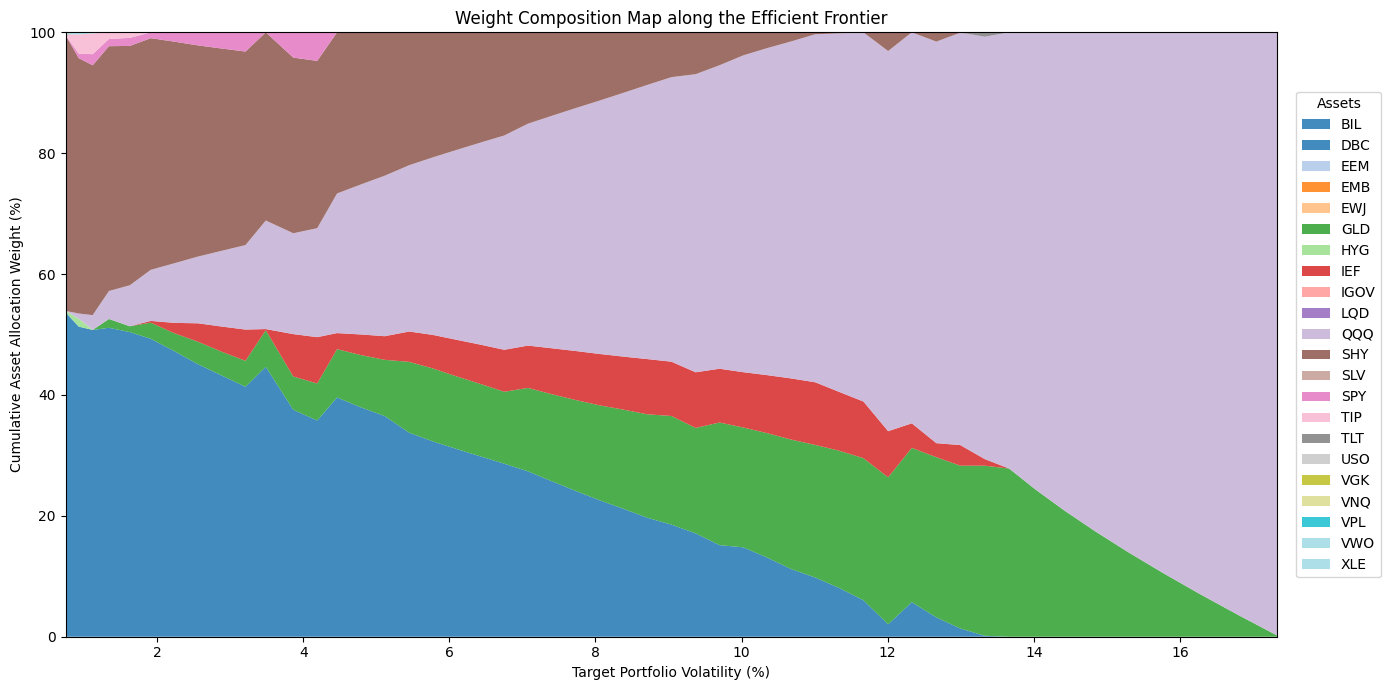

In [37]:
# Plot 4: Weight Composition along the Frontier
colors = plt.cm.tab20(np.linspace(0, 1, len(asset_names)))

plt.figure(figsize=(14, 7))
plt.stackplot(frontier_vols * 100, frontier_weights.T * 100, labels=asset_names, colors=colors, alpha=0.85)

plt.xlim(frontier_vols.min() * 100, frontier_vols.max() * 100)
plt.ylim(0, 100)
plt.xlabel('Target Portfolio Volatility (%)')
plt.ylabel('Cumulative Asset Allocation Weight (%)')
plt.title('Weight Composition Map along the Efficient Frontier')

# Place legend outside the plot for readability
plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, title="Assets")
plt.tight_layout()
plt.show()

### Max-Sharpe portfolio:

## 3. The Max-Sharpe Portfolio (Tangency Portfolio)

The optimal portfolio for a rational, risk-averse investor is the one that maximizes the risk-adjusted return, measured by the **Sharpe Ratio**. Geometrically, this portfolio is located at the point where the Capital Allocation Line (CAL) is exactly tangent to the Efficient Frontier.

### Mathematical Formulation
The objective is to maximize the Sharpe Ratio, defined as the expected excess return per unit of risk (volatility). The optimization problem is defined as:

$$\max_{w} \frac{w^T \mu - r_f}{\sqrt{w^T \Sigma w}}$$

Subject to the constraints:
1. **Fully Invested**: $\sum_{i=1}^{N} w_i = 1$ (or $w^T \mathbf{1} = 1$)
2. **Long-Only (No Short Selling)**: $w_i \ge 0 \quad \forall i$

Since optimization algorithms in Python (like `scipy.optimize.minimize`) are designed to *minimize* functions, we reformulate the problem to minimize the **negative** Sharpe Ratio.

>>> Max-Sharpe Portfolio Stats:
Expected Annual Return: 15.55%
Annual Volatility:      13.74%
Sharpe Ratio:           0.99


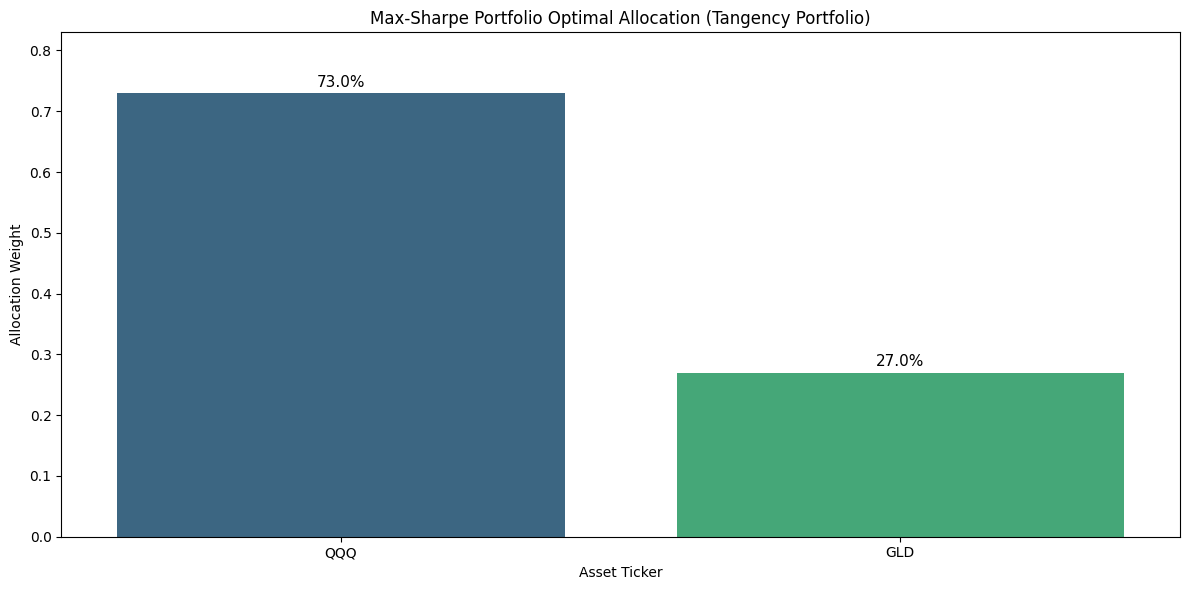

In [38]:
# Assuming mu_hist, sigma_hist, rf_rate, and asset_names are already defined from Part 2

def get_max_sharpe_weights(mu: np.ndarray, sigma_matrix: np.ndarray, rf_rate: float = 0.0) -> np.ndarray:
    """
    Computes long-only portfolio weights maximizing the Sharpe Ratio via SLSQP optimization.
    """
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets # Initial guess: Equal Weight
    
    # Objective Function: Negative Sharpe Ratio
    def neg_sharpe(w):
        p_ret = np.dot(w, mu)
        p_vol = np.sqrt(np.dot(w.T, np.dot(sigma_matrix, w)))
        if p_vol == 0: 
            return 0
        return -(p_ret - rf_rate) / p_vol

    # Constraints: Weights sum to 1
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    # Bounds: Weights between 0 and 1 (Long-Only)
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    # Optimization using Sequential Least Squares Programming (SLSQP)
    res = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, 
                   constraints=constraints, options={'ftol': 1e-10})
    
    return res.x if res.success else w0

# 1. Calculate the optimal Max-Sharpe weights
opt_weights_ms = get_max_sharpe_weights(mu_hist, sigma_hist, rf_rate)

# Calculate expected return, volatility, and Sharpe Ratio for the optimal portfolio
opt_ret_ms = np.dot(opt_weights_ms, mu_hist)
opt_vol_ms = np.sqrt(np.dot(opt_weights_ms.T, np.dot(sigma_hist, opt_weights_ms)))
opt_sharpe = (opt_ret_ms - rf_rate) / opt_vol_ms

print(f">>> Max-Sharpe Portfolio Stats:")
print(f"Expected Annual Return: {opt_ret_ms * 100:.2f}%")
print(f"Annual Volatility:      {opt_vol_ms * 100:.2f}%")
print(f"Sharpe Ratio:           {opt_sharpe:.2f}")

# 2. Prepare data for visualization (filtering out near-zero weights)
ms_weights_df = pd.DataFrame({
    'Asset': asset_names,
    'Weight': opt_weights_ms
})
# Filter out assets with virtually zero allocation to clean up the chart
ms_weights_df = ms_weights_df[ms_weights_df['Weight'] > 0.001].sort_values(by='Weight', ascending=False)

# 3. Plot the optimal asset allocation
plt.figure(figsize=(12, 6))
sns.barplot(x='Asset', y='Weight', data=ms_weights_df, hue='Asset', palette='viridis', legend=False)

plt.title('Max-Sharpe Portfolio Optimal Allocation (Tangency Portfolio)')
plt.ylabel('Allocation Weight')
plt.xlabel('Asset Ticker')
plt.ylim(0, ms_weights_df['Weight'].max() + 0.1) # Add padding on top for text

# Annotate the exact percentages on top of the bars
for index, row in enumerate(ms_weights_df.itertuples()):
    plt.text(index, row.Weight + 0.01, f"{row.Weight*100:.1f}%", color='black', ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## 4. Out-of-Sample Backtesting & Structural Robustness

Evaluating portfolio optimization techniques strictly in-sample suffers from severe look-ahead bias. The true test of an allocation strategy is its robustness out-of-sample, particularly during **regime shifts** or structural breaks such as the recent 2025-2026 stress window.

During severe market stress, the fundamental assumptions of standard Mean-Variance optimization can weaken:
1. **Correlation Convergence:** Cross-asset correlations may spike toward 1, reducing diversification benefits. The dominant eigenvalue of the sample covariance matrix $\hat{\Sigma}$ can absorb a large share of system variance.
2. **Mean Instability:** Historical sample means $\hat{\mu}$ are noisy estimators of future expected returns.

Following Michaud's critique that classical Markowitz optimization can amplify estimation error, this notebook currently compares implemented Markowitz strategies against two static benchmarks. **Michaud Resampled Efficiency is required for the final project but is not implemented yet in this draft. Black-Litterman is also not implemented and is therefore excluded from the results and interpretation.**

| Design choice | Current setting |
|---|---|
| Universe | 22 ETF multi-asset universe |
| Frequency | Monthly returns |
| Estimation window | 60 months |
| Constraints | Long-only, fully invested |
| Covariance estimator | Sample covariance matrix |
| Return estimator | Sample mean of monthly log returns, annualized |
| Target return | Dynamic convex interpolation between GMV expected return and Max-Sharpe expected return, with $\alpha = 0.5$ |
| Max-Utility risk aversion | $\lambda \in \{1, 3, 6\}$, from more aggressive to more conservative |
| Realized OOS returns | Monthly log return is converted to simple return with $\exp(r_t)-1$ before applying portfolio weights |
| Michaud simulations | Pending / not yet implemented |
| Benchmarks | Equal-Weight (1/N) and Strategic 60/40 |


In [39]:

# Complete universe
all_tickers = tickers
n_assets = len(all_tickers)

# 1. Equal Weight Benchmark (1/N)
w_ew = np.ones(n_assets) / n_assets

# 2. Strategic 60/40 Benchmark (zero-weight on tactical assets)
w_6040 = np.zeros(n_assets)
for i, t in enumerate(all_tickers):
    if t in equity_tickers:
        w_6040[i] = 0.60 / len(equity_tickers)
    elif t in bond_tickers:
        w_6040[i] = 0.40 / len(bond_tickers)
        
# Verify weights sum to 1
assert np.isclose(np.sum(w_ew), 1.0), "Equal weights must sum to 1"
assert np.isclose(np.sum(w_6040), 1.0), "60/40 weights must sum to 1"

print(f">>> Universe size: {n_assets} assets.")

>>> Universe size: 22 assets.


In [40]:
def run_rolling_backtest(returns_df: pd.DataFrame, w_eq: np.ndarray, w_6040: np.ndarray,
                          w_ew: np.ndarray, tickers: list, window: int = 60,
                          utility_lambdas: tuple = (1.0, 3.0, 6.0, 10.0)) -> pd.DataFrame:
    """
    Executes a dynamic out-of-sample backtest with monthly rolling rebalancing windows.

    Parameters
    ----------
    returns_df : pd.DataFrame
        Log returns DataFrame (monthly frequency).
    w_eq : np.ndarray
        Placeholder equilibrium weights retained for interface compatibility.
    w_6040 : np.ndarray
        Static 60/40 benchmark weights.
    w_ew : np.ndarray
        Equal-weight (1/N) benchmark weights.
    tickers : list
        List of asset tickers in the same order as returns_df columns.
    window : int
        Rolling estimation window length in months (default: 60).
    utility_lambdas : tuple
        Risk-aversion parameters for Markowitz max-utility portfolios.

    Returns
    -------
    strat_returns : pd.DataFrame
        Monthly simple returns for each implemented strategy.
    """

    oos_index = returns_df.index[window:]
    total_months = len(returns_df) - window
    utility_lambdas = tuple(float(lam) for lam in utility_lambdas)
    utility_labels = {
        lam: f"Markowitz Max-Utility (lambda={lam:g})"
        for lam in utility_lambdas
    }

    style_map = {
        'Markowitz Max-Sharpe':                 ('firebrick', '-',  2.5),
        'Markowitz Target-Return Min-Variance': ('royalblue', '-',  2.5),
        'Equal-Weight (1/N)':                   ('grey',      '--', 1.5),
        'Strategic 60/40':                      ('black',     '-.', 1.5),
    }
    utility_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(utility_lambdas)))
    for lam, color in zip(utility_lambdas, utility_colors):
        style_map[utility_labels[lam]] = (color, '-', 1.8)

    m_ms_rets      = []
    m_target_rets  = []
    utility_rets   = {lam: [] for lam in utility_lambdas}
    ew_rets        = []
    b6040_rets     = []

    print(f">>> Executing Rolling Backtest ({window}-month estimation window). {total_months} periods...")
    print(f">>> Max-Utility lambdas: {utility_lambdas}")

    for i in range(window, len(returns_df)):
        train_slice   = returns_df.iloc[i - window:i]
        realized_step = returns_df.iloc[i].values
        current_date  = returns_df.index[i]

        if (i - window) % 12 == 0:
            print(f"    - Optimizing portfolios for date: {current_date.strftime('%Y-%m')}")

        # Estimate rolling sample parameters from monthly log returns, then annualize them.
        mu_h  = train_slice.mean().values * 12
        cov_h = train_slice.cov().values  * 12

        # Strategy 1a: Markowitz Max-Sharpe / tangency portfolio.
        w_ms = get_max_sharpe_weights(mu_h, cov_h, rf_rate)

        # Strategy 1b: Markowitz minimum-variance portfolio with a dynamic target return.
        # The target is a convex interpolation between the expected return of the
        # pure GMV portfolio and the expected return of the Max-Sharpe portfolio.
        alpha       = 0.5
        w_gmv_pure  = get_gmv_weights(cov_h)
        w_ms_anchor = get_max_sharpe_weights(mu_h, cov_h, rf_rate)

        mu_gmv_anchor = np.dot(w_gmv_pure,  mu_h)
        mu_ms_anchor  = np.dot(w_ms_anchor, mu_h)

        dynamic_mu_target = (1 - alpha) * mu_gmv_anchor + alpha * mu_ms_anchor
        w_target = get_min_variance_target_return_weights(mu_h, cov_h, dynamic_mu_target)

        # Strategy 1c: Markowitz Max-Utility portfolios for different risk aversion levels.
        utility_weights = {
            lam: get_max_utility_weights(mu_h, cov_h, risk_aversion=lam)
            for lam in utility_lambdas
        }

        # Realized OOS step: convert the one-month log return vector to simple returns
        # before applying portfolio weights.
        realized_simple = np.exp(realized_step) - 1

        m_ms_rets.append(np.dot(w_ms,       realized_simple))
        m_target_rets.append(np.dot(w_target, realized_simple))
        for lam, w_utility in utility_weights.items():
            utility_rets[lam].append(np.dot(w_utility, realized_simple))
        ew_rets.append(np.dot(w_ew,         realized_simple))
        b6040_rets.append(np.dot(w_6040,    realized_simple))

    strat_returns = pd.DataFrame(index=oos_index, dtype=float)
    strat_returns['Markowitz Max-Sharpe']                 = m_ms_rets
    strat_returns['Markowitz Target-Return Min-Variance'] = m_target_rets
    for lam in utility_lambdas:
        strat_returns[utility_labels[lam]] = utility_rets[lam]
    strat_returns['Equal-Weight (1/N)']                   = ew_rets
    strat_returns['Strategic 60/40']                      = b6040_rets

    # CHART A: Out-of-Sample Wealth Index (Full Period)
    wealth_index = (1 + strat_returns).cumprod() * 100

    plt.figure(figsize=(14, 8))
    for col in wealth_index.columns:
        c, ls, lw = style_map[col]
        plt.plot(wealth_index.index, wealth_index[col],
                 label=col, color=c, linestyle=ls, linewidth=lw)

    plt.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.1,
                label='2025-2026 Stress Window')
    plt.title('Out-of-Sample Wealth Index: Markowitz Utility Sensitivity')
    plt.ylabel('Portfolio Value (Base 100)')
    plt.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

    # CHART B: Stress Zoom (Re-indexed to 100 at stress-window start)
    crisis_start = pd.Timestamp('2025-01-01')
    if strat_returns.index[-1] >= crisis_start:
        crisis_rets   = strat_returns.loc[crisis_start:]
        crisis_wealth = (1 + crisis_rets).cumprod() * 100

        plt.figure(figsize=(14, 7))
        for col in crisis_wealth.columns:
            c, ls, lw = style_map[col]
            plt.plot(crisis_wealth.index, crisis_wealth[col],
                     label=col, color=c, linestyle=ls, linewidth=lw)

        plt.axvspan('2025-12-01', '2026-04-30', color='darkred', alpha=0.15,
                    label='2025-2026 Stress Window')
        plt.title('Stress-Window Robustness: Markowitz Utility Sensitivity (Base 100 at Jan 2025)')
        plt.ylabel('Normalized Capital Value')
        plt.legend(loc='lower left', fontsize=9)
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()
    return strat_returns


>>> Data downloaded successfully. observations: 197
>>> Executing Rolling Backtest (60-month estimation window). 137 periods...
>>> Max-Utility lambdas: (1.0, 3.0, 6.0)
    - Optimizing portfolios for date: 2015-02
    - Optimizing portfolios for date: 2016-02
    - Optimizing portfolios for date: 2017-02
    - Optimizing portfolios for date: 2018-02
    - Optimizing portfolios for date: 2019-02
    - Optimizing portfolios for date: 2020-02
    - Optimizing portfolios for date: 2021-02
    - Optimizing portfolios for date: 2022-02
    - Optimizing portfolios for date: 2023-02
    - Optimizing portfolios for date: 2024-02
    - Optimizing portfolios for date: 2025-02
    - Optimizing portfolios for date: 2026-02


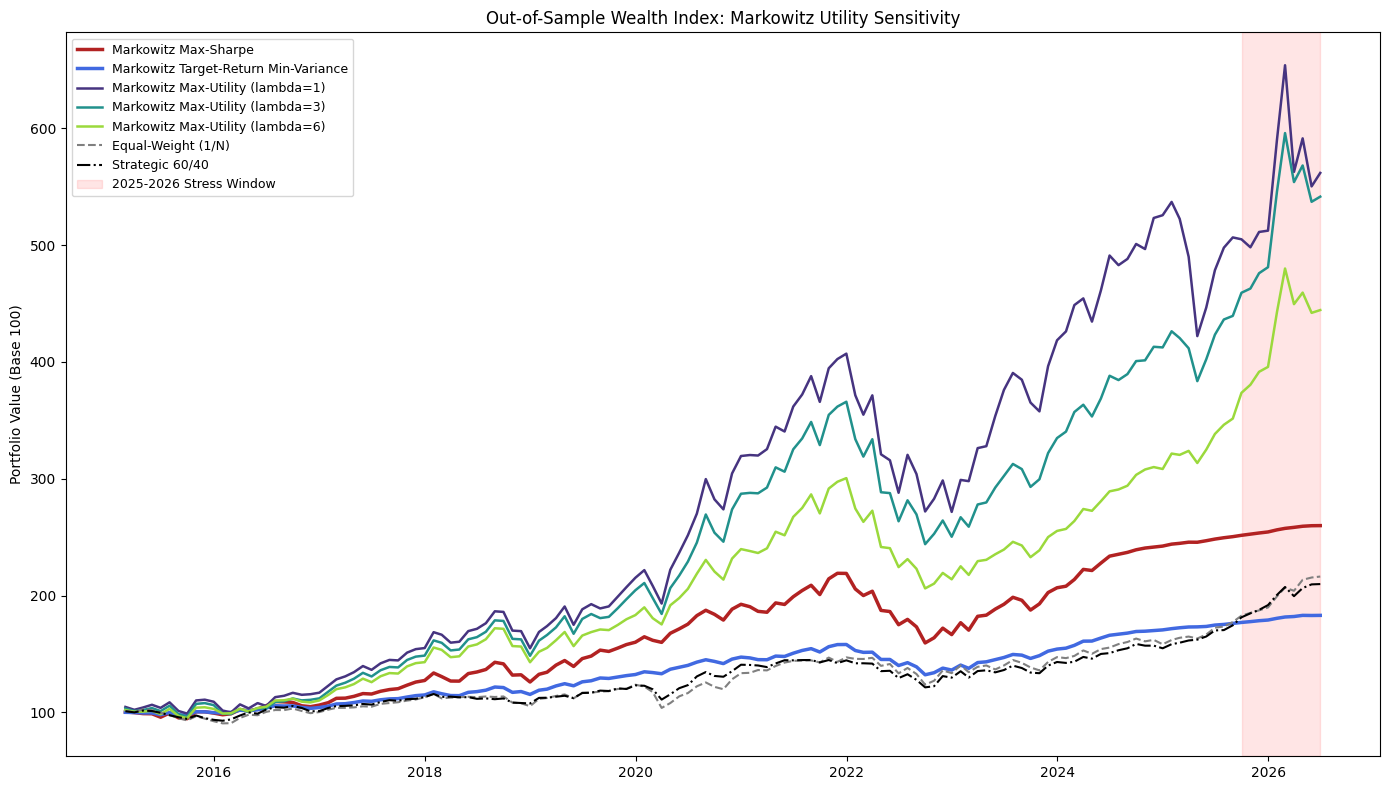

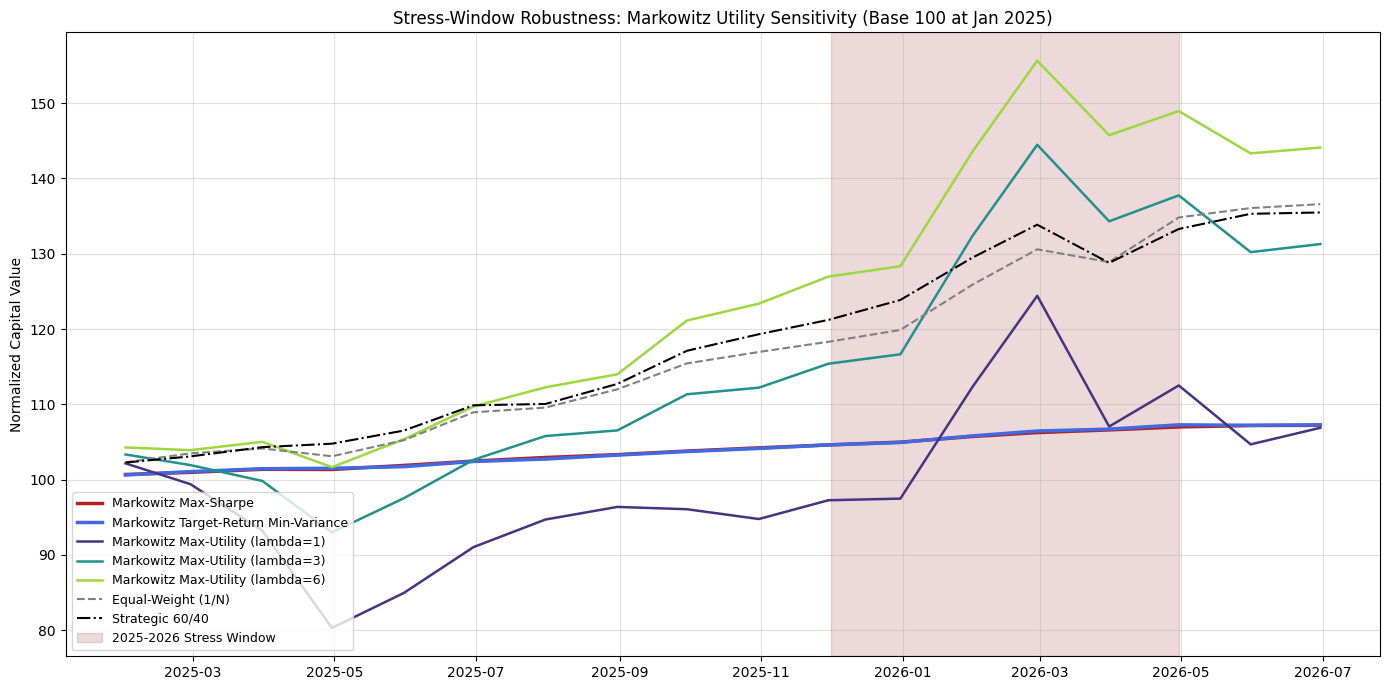

In [41]:
# 4. Resample to monthly and calculate log returns
monthly_prices_all = prices.resample('ME').last()
returns_df = np.log(monthly_prices_all / monthly_prices_all.shift(1)).dropna()

print(f">>> Data downloaded successfully. observations: {len(returns_df)}")

# 5. NOW you can safely run the backtest
utility_lambdas = (1.0, 3.0, 6.0)
oos_returns = run_rolling_backtest(
    returns_df,
    w_ew,
    w_6040,
    w_ew,
    tickers,
    window=60,
    utility_lambdas=utility_lambdas,
)


### 4.1 Performance Metrics & Interpretation

The quantitative metrics below synthesize the statistical properties of the implemented algorithms.

During a structural break, classical Markowitz portfolios can suffer large **Maximum Drawdowns** because estimation error in $\hat{\mu}$ and $\hat{\Sigma}$ may push the optimizer toward concentrated corner solutions. The Max-Sharpe portfolio is especially exposed to mean-estimation noise, while the target-return minimum-variance portfolio uses the same Markowitz framework but anchors the target return between the GMV and Max-Sharpe expected returns.

The Max-Utility portfolios solve the same mean-variance tradeoff directly through
$$U(w) = w^T\mu - \frac{\lambda}{2}w^T\Sigma w.$$
Lower $\lambda$ values accept more variance to pursue expected return, while higher $\lambda$ values penalize variance more strongly. Comparing $\lambda \in \{1,3,6,10\}$ in the OOS chart gives a sensitivity analysis of the subjective risk-aversion parameter.

At this stage, the metrics should be interpreted only for the strategies that are actually present in `oos_returns`: Markowitz Max-Sharpe, Markowitz Target-Return Min-Variance, Markowitz Max-Utility for the selected lambda values, Equal-Weight (1/N), and Strategic 60/40. Michaud Resampled Efficiency remains a required next step for the final version, but no Michaud performance result is claimed here.


In [42]:
def calculate_performance_metrics(strat_returns: pd.DataFrame, rf_rate: float = 0.02) -> pd.DataFrame:
    """Calculates compound return, annualized volatility, Sharpe Ratio, and Max Drawdown."""
    metrics = pd.DataFrame(index=strat_returns.columns)
    
    # 1. Compound Annual Growth Rate (CAGR)
    cum_returns = (1 + strat_returns).prod()
    n_years = len(strat_returns) / 12
    ann_ret = cum_returns ** (1 / n_years) - 1
    metrics['CAGR (%)'] = ann_ret * 100
    
    # 2. Annualized Volatility
    ann_vol = strat_returns.std() * np.sqrt(12)
    metrics['Ann. Volatility (%)'] = ann_vol * 100
    
    # 3. Sharpe Ratio
    metrics['Sharpe Ratio'] = (ann_ret - rf_rate) / ann_vol
    
    # 4. Maximum Drawdown (Risk mapping)
    wealth_index = (1 + strat_returns).cumprod()
    peak = wealth_index.cummax()
    drawdown = (wealth_index - peak) / peak
    metrics['Max Drawdown (%)'] = drawdown.min() * 100
    
    return metrics.round(2)

# Uncomment to execute after running the backtest
metrics_df = calculate_performance_metrics(oos_returns, rf_rate=0.02)
print("\n=== OUT-OF-SAMPLE METRICS (Full Period) ===")
print(metrics_df.to_string())


=== OUT-OF-SAMPLE METRICS (Full Period) ===
                                      CAGR (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)
Markowitz Max-Sharpe                      8.73                 9.83          0.68            -27.20
Markowitz Target-Return Min-Variance      5.44                 5.14          0.67            -16.39
Markowitz Max-Utility (lambda=1)         16.32                19.51          0.73            -33.27
Markowitz Max-Utility (lambda=3)         15.95                16.68          0.84            -33.32
Markowitz Max-Utility (lambda=6)         13.96                13.88          0.86            -31.41
Equal-Weight (1/N)                        6.99                 9.48          0.53            -16.05
Strategic 60/40                           6.71                 8.02          0.59            -16.16


## 5. Dynamic Portfolio Recomposition (Weight Turnover)

To understand the practical feasibility of an optimization model, we must analyze its **turnover**: how drastically the allocation weights change over time.

In our rolling backtest, the portfolio is re-optimized **monthly** based on a trailing 60-month window. The classical Markowitz Max-Sharpe model is highly sensitive to small changes in the input parameters ($\mu$ and $\Sigma$). Consequently, as the rolling window drops one old observation and adds a new one, the optimal weights can jump aggressively from one asset class to another.

The following area chart visualizes the temporal evolution of the Markowitz Max-Sharpe weights. The turnover table later in this section turns that visual instability into a numerical metric.


>>> Extracting historical weights for Markowitz Max-Sharpe...


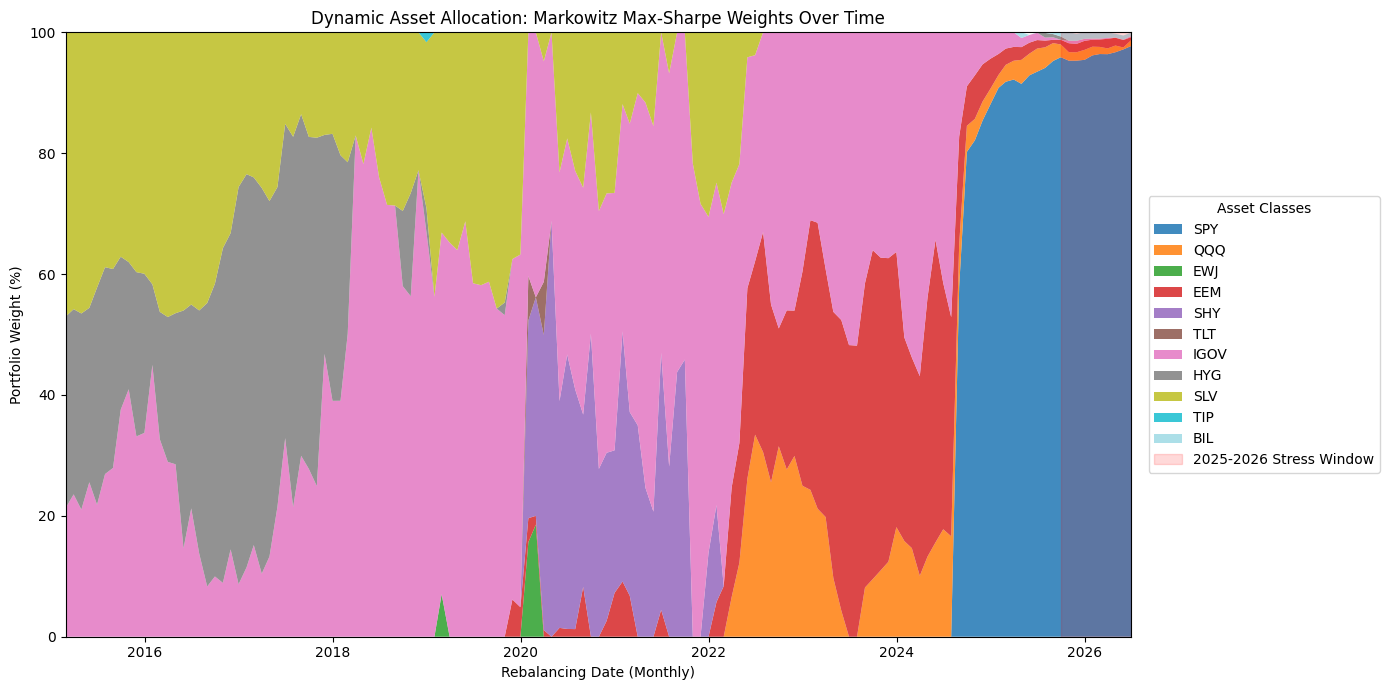

In [43]:
# Creiamo un DataFrame per immagazzinare la storia dei pesi Max-Sharpe
window = 60
oos_index = returns_df.index[window:]
markowitz_weights_history = pd.DataFrame(index=oos_index, columns=all_tickers)

print(">>> Extracting historical weights for Markowitz Max-Sharpe...")

for i in range(window, len(returns_df)):
    train_slice = returns_df.iloc[i-window:i]
    
    # Stima rolling dei parametri da log returns mensili annualizzati
    mu_h = train_slice.mean().values * 12
    cov_h = train_slice.cov().values * 12
    
    # Calcolo dei pesi ottimali per quel mese
    w_mv = get_max_sharpe_weights(mu_h, cov_h, rf_rate)
    
    # Salviamo i pesi nel DataFrame
    markowitz_weights_history.iloc[i-window] = w_mv

# Rimuoviamo gli asset che non sono mai stati scelti dall'algoritmo (peso sempre vicino a 0)
# per mantenere il grafico pulito
threshold = 0.01 # 1%
max_weights = markowitz_weights_history.max()
active_assets = max_weights[max_weights > threshold].index
filtered_weights_history = markowitz_weights_history[active_assets].astype(float) * 100

# Preparazione del grafico ad area (Stackplot)
plt.figure(figsize=(14, 7))

# Generiamo una palette di colori coerente
colors = plt.cm.tab20(np.linspace(0, 1, len(active_assets)))

plt.stackplot(filtered_weights_history.index, 
              filtered_weights_history.T, 
              labels=active_assets, 
              colors=colors, 
              alpha=0.85)

plt.title('Dynamic Asset Allocation: Markowitz Max-Sharpe Weights Over Time')
plt.ylabel('Portfolio Weight (%)')
plt.xlabel('Rebalancing Date (Monthly)')
plt.xlim(filtered_weights_history.index.min(), filtered_weights_history.index.max())
plt.ylim(0, 100)

# Evidenziamo la finestra di stress recente
plt.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.15, label='2025-2026 Stress Window')

# Posizioniamo la legenda fuori dal grafico
plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, title="Asset Classes")
plt.tight_layout()
plt.show()


### 5.1 Markowitz Target-Return Minimum-Variance Turnover

The second dynamic allocation is **not** a pure GMV portfolio. It is a Markowitz minimum-variance portfolio subject to a dynamic target return.

At each rolling date, the target return is selected as a convex interpolation between the expected return of the pure GMV portfolio and the expected return of the Max-Sharpe portfolio:
$$\mu^*_{target} = (1 - \alpha)\mu_{GMV} + \alpha\mu_{MS}, \quad \alpha = 0.5$$

The resulting optimization is:
$$\min_{w} w^T \Sigma w \quad \text{s.t.} \quad w^T \mathbf{1} = 1, \quad w^T\mu = \mu^*_{target}, \quad w \ge 0$$

This keeps the target return feasible by construction and avoids labeling the strategy as GMV when it is actually a target-return minimum-variance portfolio.


>>> Extracting historical weights for Markowitz Target-Return Min-Variance...


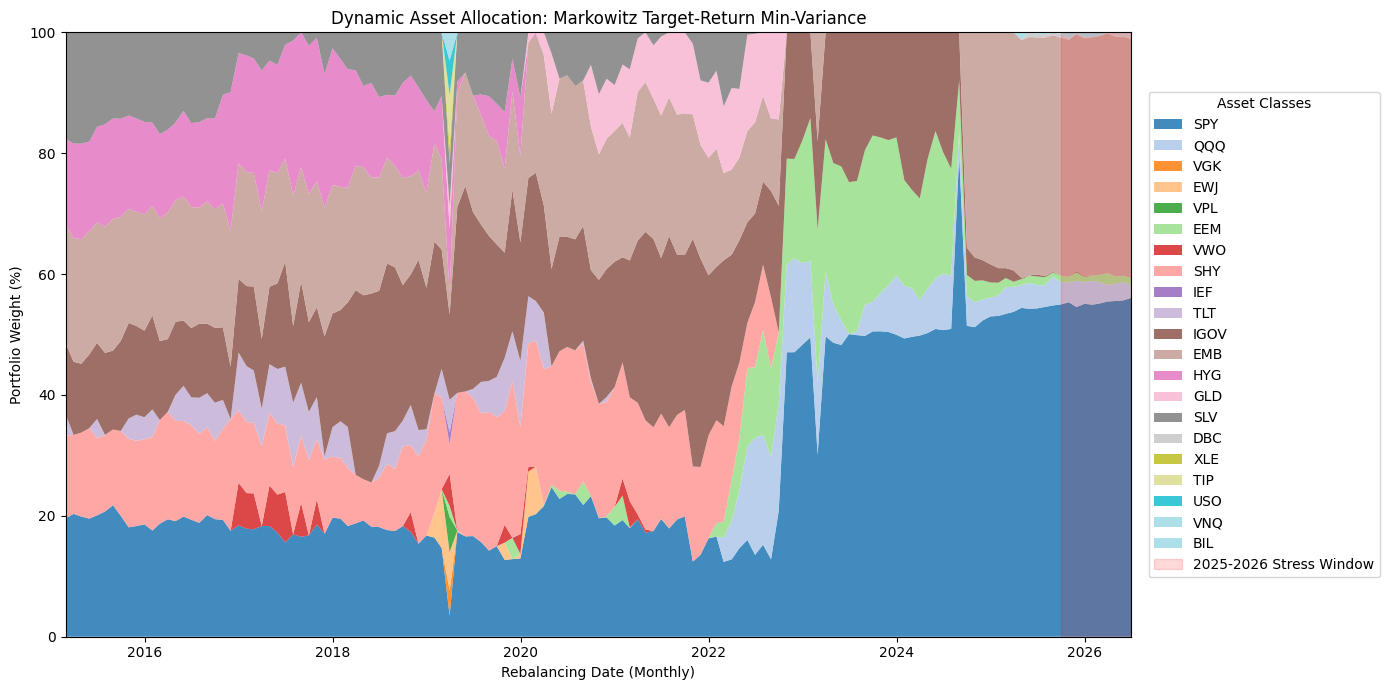


=== AVERAGE MONTHLY TURNOVER ===
                                      Average Monthly Turnover (%)
Markowitz Max-Sharpe                                          8.74
Markowitz Target-Return Min-Variance                          7.20


In [44]:
# Inizializziamo il DataFrame per la storia dei pesi del Target-Return Min-Variance
target_mv_weights_history = pd.DataFrame(index=oos_index, columns=all_tickers)

print(">>> Extracting historical weights for Markowitz Target-Return Min-Variance...")

for i in range(window, len(returns_df)):
    train_slice = returns_df.iloc[i-window:i]
    
    # Stima rolling dei parametri da log returns mensili annualizzati
    mu_h = train_slice.mean().values * 12
    cov_h = train_slice.cov().values * 12

    # Anchor portfolios calcolati solo sulla finestra rolling corrente: niente full-sample look-ahead.
    weights_gmv = get_gmv_weights(cov_h)
    weights_ms = get_max_sharpe_weights(mu_h, cov_h, rf_rate)

    # Expected returns degli anchor sulla stessa finestra rolling.
    mu_gmv = np.dot(weights_gmv, mu_h)
    mu_ms = np.dot(weights_ms, mu_h)

    # Target return dinamico: interpolazione convessa tra GMV e Max-Sharpe.
    alpha = 0.5 
    dynamic_mu_target = (1 - alpha) * mu_gmv + alpha * mu_ms
    w_target_mv = get_min_variance_target_return_weights(mu_h, cov_h, dynamic_mu_target)

    target_mv_weights_history.iloc[i-window] = w_target_mv

# Filtriamo gli asset irrilevanti per la visualizzazione
active_assets_target = target_mv_weights_history.max()[target_mv_weights_history.max() > threshold].index
filtered_target_weights = target_mv_weights_history[active_assets_target].astype(float) * 100

# Plot della ricomposizione del portafoglio Target-Return Min-Variance
plt.figure(figsize=(14, 7))

# Usiamo la stessa logica per i colori
colors_target = plt.cm.tab20(np.linspace(0, 1, len(active_assets_target)))

plt.stackplot(filtered_target_weights.index, 
              filtered_target_weights.T, 
              labels=active_assets_target, 
              colors=colors_target, 
              alpha=0.85)

plt.title('Dynamic Asset Allocation: Markowitz Target-Return Min-Variance')
plt.ylabel('Portfolio Weight (%)')
plt.xlabel('Rebalancing Date (Monthly)')
plt.xlim(filtered_target_weights.index.min(), filtered_target_weights.index.max())
plt.ylim(0, 100)

# Zona di stress recente
plt.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.15, label='2025-2026 Stress Window')

plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, title="Asset Classes")
plt.tight_layout()
plt.show()

# Turnover numerico: turnover_t = 0.5 * sum(abs(w_t - w_{t-1}))
def calculate_average_turnover(weights_history: pd.DataFrame) -> float:
    weights = weights_history.astype(float)
    turnover = 0.5 * weights.diff().abs().sum(axis=1)
    return turnover.dropna().mean()

turnover_df = pd.DataFrame({
    'Average Monthly Turnover': {
        'Markowitz Max-Sharpe': calculate_average_turnover(markowitz_weights_history),
        'Markowitz Target-Return Min-Variance': calculate_average_turnover(target_mv_weights_history),
    }
})
turnover_df['Average Monthly Turnover (%)'] = turnover_df['Average Monthly Turnover'] * 100

print("\n=== AVERAGE MONTHLY TURNOVER ===")
print(turnover_df[['Average Monthly Turnover (%)']].round(2).to_string())
